# FunnyBirds CBM — Counterfactual Concept Swap

**Motivation:** recall gaps in `fb_recallv2.ipynb` show that a concept probe fires
differently across species even when both truly have the concept.  But a recall gap is a
behavioural proxy — it could reflect visual confounding in the backbone rather than
species identity leaking *through the concept bottleneck itself*.

**This notebook tests the mechanism directly** using the CBM's own bottleneck and label head:

1. **Counterfactual swap** — For an all-positive pair (species A, B, concept C):
   take species-A test images → compute concept activations z_A ∈ ℝ^26 → replace
   z_A[C] with z_B[C] (same concept, different species donor) → run label head.
   If P(species B) rises: z_C was carrying species-B identity.

2. **Species-identity probe on z** — train a linear classifier `z → species_id`.
   If z alone predicts species, the bottleneck is leaking species identity.

3. **Per-concept binary discriminability** — for each concept C, train a binary
   classifier `z_C (scalar) → {A, B}`.  Above-chance = z_C distinguishes species
   beyond merely whether the concept is present.

Data-loading follows `fb_recallv2.ipynb` exactly.

In [1]:
%matplotlib inline
import json
import random
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats

## 0. Paths and configuration

In [2]:
import sys
ROOT = Path('/scratch/network/cr7998/cv_emergence_project')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FB        = ROOT / 'data'     / 'FunnyBirds'
CBM_FEATS = ROOT / 'features' / 'resnet50_cbm_funnybirds'
CBM_CKPT  = ROOT / 'checkpoints_funnybirds' / 'cbm_funnybirds.pth'

assert FB.exists(),        f'Missing FunnyBirds folder: {FB}'
assert CBM_FEATS.exists(), f'Missing CBM features: {CBM_FEATS}'
assert CBM_CKPT.exists(),  f'Missing CBM checkpoint: {CBM_CKPT}'

N_SPECIES    = 50
N_CONCEPTS   = 26
PROBE_EPOCHS = 30

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[config] device: {device}')
print(f'[config] CBM checkpoint: {CBM_CKPT}')

[config] device: cpu
[config] CBM checkpoint: /scratch/network/cr7998/cv_emergence_project/checkpoints_funnybirds/cbm_funnybirds.pth


## 1. Data-loading helpers  *(from fb_recallv2.py)*

In [3]:
def load_species_maps(fb_root: Path):
    """Load species ID→name mappings from FunnyBirds metadata/classes.csv."""
    classes_csv = fb_root / 'metadata' / 'classes.csv'
    if not classes_csv.exists():
        raise FileNotFoundError(
            'metadata/classes.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(classes_csv)
    id2name  = dict(zip(df['class_id'], df['class_name']))
    id2short = {k: v.replace('funnybird_', 'FB') for k, v in id2name.items()}
    return id2name, id2short


def load_meta(fb_root: Path) -> pd.DataFrame:
    """Per-image metadata: image_id, class_id, species_id, species_name, is_train."""
    images_csv = fb_root / 'metadata' / 'images.csv'
    if not images_csv.exists():
        raise FileNotFoundError(
            'metadata/images.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(images_csv)
    id2name, _ = load_species_maps(fb_root)
    df['species_id']   = df['class_id']
    df['species_name'] = df['class_id'].map(id2name)
    return df


def load_image_attr_labels_robust(fb_root: Path) -> pd.DataFrame:
    """
    Long-form per-image concept labels: image_id, attr_id, attr_name, is_present, certainty.
    certainty is always 1 for FunnyBirds (ground-truth, no annotation noise).
    """
    concepts_csv = fb_root / 'metadata' / 'image_concepts_binary.csv'
    if not concepts_csv.exists():
        raise FileNotFoundError(
            'metadata/image_concepts_binary.csv not found. '
            'Run prepare_funnybirds_metadata.py first.')
    wide = pd.read_csv(concepts_csv)
    concept_cols = [c for c in wide.columns if c != 'image_id']
    long = wide.melt(id_vars='image_id', value_vars=concept_cols,
                     var_name='attr_name', value_name='is_present')
    long['attr_id']    = long.groupby('attr_name', sort=False).ngroup()
    long['is_present'] = long['is_present'].astype(int)
    long['certainty']  = 1
    return long[['image_id', 'attr_id', 'attr_name', 'is_present', 'certainty']]


def load_attr_maps(fb_root: Path):
    """Concept name↔id from metadata/concepts.csv."""
    concepts_csv = fb_root / 'metadata' / 'concepts.csv'
    if not concepts_csv.exists():
        raise FileNotFoundError(
            'metadata/concepts.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(concepts_csv)
    id2name = dict(zip(df['concept_id'], df['concept_name']))
    name2id = dict(zip(df['concept_name'], df['concept_id']))
    return id2name, name2id


def build_attr_labeled_df(
    meta: pd.DataFrame,
    img_attr_long: pd.DataFrame,
    attr_id: int,
    min_certainty: int = 1,
) -> pd.DataFrame:
    """image_id, species_id, species_name, is_train, y, certainty for one concept."""
    sub = img_attr_long[img_attr_long['attr_id'] == int(attr_id)].copy()
    sub = sub[sub['certainty'] >= int(min_certainty)].copy()
    out = meta.merge(sub[['image_id', 'is_present', 'certainty']], on='image_id', how='inner')
    out = out.rename(columns={'is_present': 'y'})
    out['y'] = out['y'].astype(int)
    return out[['image_id', 'species_id', 'species_name', 'is_train', 'y', 'certainty']]


print('Defined: load_species_maps  load_meta  load_image_attr_labels_robust')
print('         load_attr_maps  build_attr_labeled_df')

Defined: load_species_maps  load_meta  load_image_attr_labels_robust
         load_attr_maps  build_attr_labeled_df


In [4]:
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=True)
    except TypeError:
        return torch.load(path, map_location='cpu')


def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    p = feat_dir / f'{layer}_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()


def to_1d_int_array(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)


def infer_kind(arr):
    if arr.max() <= 200 and arr.min() >= 0:
        return 'species_id_like'
    if arr.max() > 200:
        return 'image_id_like'
    return 'unknown'


def load_split_order(feat_dir: Path, split: str):
    p = feat_dir / f'labels_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    t = safe_torch_load(p)
    assert isinstance(t, dict), f'Expected dict in {p}, got {type(t)}'
    assert 'image_ids' in t, f'{p} missing image_ids; has {list(t.keys())}'
    ids  = to_1d_int_array(t['image_ids'])
    kind = infer_kind(ids)
    return kind, ids


def align_features_and_labels(
    X_split: torch.Tensor,
    image_ids_in_feature_order: np.ndarray,
    labeled_df_split: pd.DataFrame,
):
    """
    Align feature rows to attribute labels by image_id.
    Returns X_aligned [M, D] and df_aligned [M rows] in the same order.
    """
    labeled  = labeled_df_split.set_index('image_id')[['y', 'species_id', 'species_name']]
    keep_idx = []
    rows     = []
    for i, img_id in enumerate(image_ids_in_feature_order):
        img_id = int(img_id)
        if img_id in labeled.index:
            keep_idx.append(i)
            y, sid, sname = labeled.loc[img_id]
            rows.append((img_id, int(sid), str(sname), int(y)))
    X_aligned  = X_split[keep_idx]
    df_aligned = pd.DataFrame(rows, columns=['image_id', 'species_id', 'species_name', 'y'])
    return X_aligned, df_aligned


print('Defined: safe_torch_load  load_features  load_split_order')
print('         to_1d_int_array  infer_kind  align_features_and_labels')

Defined: safe_torch_load  load_features  load_split_order
         to_1d_int_array  infer_kind  align_features_and_labels


## 2. Concept names, class-concept matrix, metadata

In [5]:
from datasets.funnybirds_dataset import FunnyBirdsDataset
from datasets.funnybirds_dataset import concept_names as _fb_concept_names

CONCEPT_NAMES  = _fb_concept_names()   # 26 strings: ['beak_0', 'beak_1', ...]
CONCEPT_TO_IDX = {c: i for i, c in enumerate(CONCEPT_NAMES)}

PART_GROUPS = {
    part: [i for i, c in enumerate(CONCEPT_NAMES) if c.startswith(f'{part}_')]
    for part in ['beak', 'wing', 'tail', 'foot', 'eye']
}
PART_COLORS = {
    'beak': 'steelblue', 'wing': 'seagreen', 'tail': 'crimson',
    'foot': 'darkorange', 'eye': 'purple',
}
CONCEPT_TO_PART = {
    c: part
    for part, idxs in PART_GROUPS.items()
    for c in [CONCEPT_NAMES[i] for i in idxs]
}

# Exact class-concept matrix — no annotation noise (key FunnyBirds advantage)
_fb_ds    = FunnyBirdsDataset(FB, split='train')
cc_matrix, _ = _fb_ds.get_class_concept_matrix()   # [50, 26] int tensor
cc_matrix = cc_matrix.numpy()

cc_df = pd.DataFrame(
    cc_matrix,
    columns=CONCEPT_NAMES,
    index=[f'funnybird_{i:02d}' for i in range(N_SPECIES)],
)
print(f'Concepts ({len(CONCEPT_NAMES)}): {CONCEPT_NAMES}')
print(f'CC matrix: {cc_matrix.shape}  — each row sums to {cc_matrix.sum(1).mean():.0f}')
cc_df.head()

Concepts (26): ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']
CC matrix: (50, 26)  — each row sums to 4


,beak_0,beak_1,beak_2,beak_3,eye_0,eye_1,eye_2,wing_0,wing_1,wing_2,...,foot_3,tail_0,tail_1,tail_2,tail_3,tail_4,tail_5,tail_6,tail_7,tail_8
funnybird_00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
funnybird_01,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
funnybird_02,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
funnybird_03,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
funnybird_04,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Load metadata and attribute maps — same as fb_recallv2.py cell 6
meta          = load_meta(FB)
img_attr_long = load_image_attr_labels_robust(FB)
attr_id_to_name, attr_name_to_id = load_attr_maps(FB)

attr_df = pd.DataFrame({
    'attr_name': list(attr_name_to_id.keys()),
    'attr_id':   list(attr_name_to_id.values()),
})

id2name, _ = load_species_maps(FB)
def spname(sid: int) -> str:
    return id2name.get(int(sid), f'funnybird_{int(sid):02d}')

print(f'meta:          {len(meta)} images  '
      f'({meta["is_train"].sum()} train, {(meta["is_train"]==0).sum()} test)')
print(f'img_attr_long: {len(img_attr_long)} rows, '
      f'{img_attr_long["attr_name"].nunique()} concepts')
print(f'Concepts: {list(attr_name_to_id.keys())}')

meta:          50500 images  (50000 train, 500 test)
img_attr_long: 1313000 rows, 26 concepts
Concepts: ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']


In [7]:
# Load split ordering (image_ids in DataLoader order)
cbm_kind_tr, cbm_ids_tr = load_split_order(CBM_FEATS, 'train')
cbm_kind_te, cbm_ids_te = load_split_order(CBM_FEATS, 'test')

print(f'CBM train: {cbm_kind_tr}  id range: ({cbm_ids_tr.min()}, {cbm_ids_tr.max()})')
print(f'CBM test:  {cbm_kind_te}  id range: ({cbm_ids_te.min()}, {cbm_ids_te.max()})')
print(f'Train N={len(cbm_ids_tr)}  Test N={len(cbm_ids_te)}')

CBM train: image_id_like  id range: (0, 49999)
CBM test:  image_id_like  id range: (50000, 50499)
Train N=50000  Test N=500


## 3. Load CBM weights and compute concept activations

Architecture: `backbone → avgpool [2048] → concept_head [26] → sigmoid → label_head [50]`

- **avgpool features** already extracted at `CBM_FEATS/avgpool_{split}.pt`
- **concept_head** (`W_c [26, 2048]`, `b_c [26]`) and **label_head** (`W_y [50, 26]`,
  `b_y [50]`) from checkpoint

`z = sigmoid(avgpool @ W_c.T + b_c)` — the 26-dim concept bottleneck activation.

In [8]:
ckpt = safe_torch_load(CBM_CKPT)
sd   = ckpt.get('model_state_dict', ckpt)

W_c = sd['concept_head.weight'].float()   # [26, 2048]
b_c = sd['concept_head.bias'].float()     # [26]
W_y = sd['label_head.weight'].float()     # [50, 26]
b_y = sd['label_head.bias'].float()       # [50]

print(f'concept_head: {tuple(W_c.shape)}  bias: {tuple(b_c.shape)}')
print(f'label_head:   {tuple(W_y.shape)}  bias: {tuple(b_y.shape)}')
cfg = ckpt.get('config', {})
if cfg:
    print(f'config: {cfg}')

concept_head: (26, 2048)  bias: (26,)
label_head:   (50, 26)  bias: (50,)
config: {'num_concepts': 26, 'num_classes': 50, 'lambda_c': 1.0, 'concept_names': ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8'], 'dataset': 'funnybirds'}


In [9]:
# Load avgpool features and compute z for train + test splits
avg_te = load_features(CBM_FEATS, 'avgpool', 'test')
avg_tr = load_features(CBM_FEATS, 'avgpool', 'train')

# Align metadata to feature order (same pattern as fb_recallv2.py)
meta_tr = meta[meta['is_train'] == 1].copy()
meta_te = meta[meta['is_train'] == 0].copy()

# Use any concept to get the aligned species_ids — we just need the image_id → species_id map
_meta_idx = meta.set_index('image_id')
sids_te = np.array([int(_meta_idx.loc[int(i), 'species_id']) for i in cbm_ids_te])
sids_tr = np.array([int(_meta_idx.loc[int(i), 'species_id']) for i in cbm_ids_tr])

@torch.no_grad()
def compute_z(avgpool: torch.Tensor) -> torch.Tensor:
    """z = sigmoid(avgpool @ W_c.T + b_c)  [N, 26]"""
    return torch.sigmoid(avgpool @ W_c.T + b_c)

@torch.no_grad()
def compute_logits(z: torch.Tensor) -> torch.Tensor:
    """logits = z @ W_y.T + b_y  [N, 50]"""
    return z @ W_y.T + b_y

z_te = compute_z(avg_te)   # [N_te, 26]
z_tr = compute_z(avg_tr)   # [N_tr, 26]

print(f'avgpool_te: {tuple(avg_te.shape)}  →  z_te: {tuple(z_te.shape)}')
print(f'avgpool_tr: {tuple(avg_tr.shape)}  →  z_tr: {tuple(z_tr.shape)}')

avgpool_te: (500, 2048)  →  z_te: (500, 26)
avgpool_tr: (50000, 2048)  →  z_tr: (50000, 26)


In [10]:
# Sanity: species accuracy
logits_te = compute_logits(z_te)
pred_sp   = logits_te.argmax(dim=1).numpy()
sp_acc    = float((pred_sp == sids_te).mean())
print(f'CBM test species accuracy: {sp_acc:.4f}')

# Sanity: concept accuracy vs GT class-concept matrix
gt_concepts  = cc_matrix[sids_te]                      # [N_te, 26]
pred_concepts = (z_te.numpy() > 0.5).astype(int)
print(f'CBM concept accuracy (threshold=0.5): {(pred_concepts == gt_concepts).mean():.4f}')
print('Per-concept:')
for name, acc in zip(CONCEPT_NAMES, (pred_concepts == gt_concepts).mean(axis=0)):
    print(f'  {name:12s}: {acc:.3f}')

CBM test species accuracy: 0.9660
CBM concept accuracy (threshold=0.5): 0.9523
Per-concept:
  beak_0      : 0.886
  beak_1      : 0.934
  beak_2      : 0.988
  beak_3      : 0.946
  eye_0       : 0.968
  eye_1       : 0.894
  eye_2       : 0.932
  wing_0      : 1.000
  wing_1      : 0.954
  wing_2      : 0.980
  wing_3      : 0.956
  wing_4      : 0.958
  wing_5      : 0.956
  foot_0      : 0.976
  foot_1      : 0.902
  foot_2      : 0.920
  foot_3      : 0.940
  tail_0      : 0.982
  tail_1      : 0.972
  tail_2      : 0.944
  tail_3      : 0.972
  tail_4      : 0.972
  tail_5      : 0.936
  tail_6      : 0.954
  tail_7      : 0.984
  tail_8      : 0.954


## 4. Counterfactual concept swap

For an all-positive pair (species A, species B, concept C):

```
z_swapped = z_A  but  z_swapped[:, C] ← z_B[:, C]
logits_swapped = z_swapped @ W_y.T + b_y
shift_B = mean(softmax(logits_swapped)[:, B]) − mean(softmax(logits_A)[:, B])
```

- `shift_B > 0` → swapping z_C from B into A raised P(species B) → z_C carries B-identity
- `leakage_sym = 0.5 * (leakage_fwd + leakage_bwd)` — symmetric, both directions averaged

In [11]:
@torch.no_grad()
def concept_swap(
    z_A: torch.Tensor,   # [N_A, K]  recipient
    z_B: torch.Tensor,   # [N_B, K]  donor
    concept_idx: int,
):
    """
    For every A-image: replace z_A[:, concept_idx] with each of the N_B donor values,
    average the resulting softmax probabilities over donors.
    Returns p_orig [N_A, n_sp] and p_swap [N_A, n_sp].
    """
    N_A, K = z_A.shape
    N_B    = z_B.shape[0]

    p_orig = torch.softmax(z_A @ W_y.T + b_y, dim=-1)          # [N_A, n_sp]

    z_swap = z_A.unsqueeze(1).expand(N_A, N_B, K).clone()       # [N_A, N_B, K]
    z_swap[:, :, concept_idx] = z_B[:, concept_idx].unsqueeze(0)

    logits_swap = z_swap.view(N_A * N_B, K) @ W_y.T + b_y       # [N_A*N_B, n_sp]
    p_swap = torch.softmax(logits_swap, dim=-1).view(N_A, N_B, -1).mean(dim=1)

    return p_orig, p_swap


def pair_swap_metrics(sid_A: int, sid_B: int, concept_idx: int):
    """
    Symmetric leakage score for (species A, species B, concept C).
    leakage_sym > 0 → z_C carries species-identity signal.
    """
    mask_A = sids_te == sid_A
    mask_B = sids_te == sid_B
    z_A    = z_te[mask_A]
    z_B    = z_te[mask_B]
    if len(z_A) == 0 or len(z_B) == 0:
        return None

    p_orig_A, p_swap_A = concept_swap(z_A, z_B, concept_idx)
    shift_B_fwd = (p_swap_A[:, sid_B] - p_orig_A[:, sid_B]).mean().item()
    shift_A_fwd = (p_swap_A[:, sid_A] - p_orig_A[:, sid_A]).mean().item()

    p_orig_B, p_swap_B = concept_swap(z_B, z_A, concept_idx)
    shift_A_bwd = (p_swap_B[:, sid_A] - p_orig_B[:, sid_A]).mean().item()
    shift_B_bwd = (p_swap_B[:, sid_B] - p_orig_B[:, sid_B]).mean().item()

    leakage_fwd = shift_B_fwd - shift_A_fwd
    leakage_bwd = shift_A_bwd - shift_B_bwd
    leakage_sym = 0.5 * (leakage_fwd + leakage_bwd)

    return {
        'sid_A': int(sid_A), 'sid_B': int(sid_B),
        'concept_idx': int(concept_idx), 'concept': CONCEPT_NAMES[concept_idx],
        'shift_B_fwd': float(shift_B_fwd),
        'shift_A_fwd': float(shift_A_fwd),
        'shift_A_bwd': float(shift_A_bwd),
        'shift_B_bwd': float(shift_B_bwd),
        'leakage_fwd': float(leakage_fwd),
        'leakage_bwd': float(leakage_bwd),
        'leakage_sym': float(leakage_sym),
        'n_A': int(mask_A.sum()),
        'n_B': int(mask_B.sum()),
    }


print('Defined: concept_swap  pair_swap_metrics')

Defined: concept_swap  pair_swap_metrics


## 5. Run swaps for all GT-positive pairs

In [12]:
swap_rows = []

for c_idx, c_name in enumerate(CONCEPT_NAMES):
    positive_sids = np.where(cc_matrix[:, c_idx] == 1)[0]
    if len(positive_sids) < 2:
        continue
    for sid_A, sid_B in combinations(positive_sids, 2):
        r = pair_swap_metrics(sid_A, sid_B, c_idx)
        if r is not None:
            swap_rows.append(r)

swap_df = pd.DataFrame(swap_rows)
swap_df['part'] = swap_df['concept'].map(CONCEPT_TO_PART)

print(f'Swap results: {len(swap_df)} rows  ({swap_df["concept"].nunique()} concepts)')
print(f'leakage_sym  mean={swap_df["leakage_sym"].mean():.4f}  '
      f'median={swap_df["leakage_sym"].median():.4f}  '
      f'max={swap_df["leakage_sym"].max():.4f}')
swap_df.head(10)

Swap results: 850 rows  (26 concepts)
leakage_sym  mean=-0.0038  median=-0.0001  max=0.0464


,sid_A,sid_B,concept_idx,concept,shift_B_fwd,shift_A_fwd,shift_A_bwd,shift_B_bwd,leakage_fwd,leakage_bwd,leakage_sym,n_A,n_B,part
0,3,8,0,beak_0,-1.114015e-07,-0.000118,-1.224331e-08,0.000201,0.000118,-0.000201,-4.188938e-05,10,10,beak
1,3,10,0,beak_0,-1.419476e-08,-0.000003,-9.612453e-11,0.000024,0.000003,-0.000024,-1.071810e-05,10,10,beak
2,3,17,0,beak_0,-1.813496e-08,0.000017,1.356993e-08,-0.000016,-0.000017,0.000016,-6.340921e-07,10,10,beak
3,3,18,0,beak_0,-9.407218e-05,-0.006897,2.581064e-05,0.084180,0.006803,-0.084155,-3.867605e-02,10,10,beak
4,3,21,0,beak_0,-2.128545e-06,-0.004853,-2.462120e-08,0.015699,0.004851,-0.015699,-5.424075e-03,10,10,beak
5,3,24,0,beak_0,1.001217e-08,-0.000218,1.051018e-09,-0.000221,0.000218,0.000221,2.198006e-04,10,10,beak
6,3,25,0,beak_0,1.433176e-09,-0.000209,1.962962e-09,0.000279,0.000209,-0.000279,-3.518739e-05,10,10,beak
7,3,26,0,beak_0,1.266372e-10,0.000016,2.107754e-10,-0.000005,-0.000016,0.000005,-5.407463e-06,10,10,beak
8,3,27,0,beak_0,3.415753e-08,-0.000086,4.949425e-09,-0.000021,0.000086,0.000021,5.375761e-05,10,10,beak
9,3,29,0,beak_0,1.088829e-06,-0.002672,7.464249e-07,0.002559,0.002674,-0.002558,5.755543e-05,10,10,beak


In [28]:
swap_df.to_csv('fb_cbm_counterfactual_swap.csv', index=False)
print('Saved fb_cbm_counterfactual_swap.csv')

Saved fb_cbm_counterfactual_swap.csv


## 6. Per-concept and per-part aggregation

In [14]:
concept_agg = (
    swap_df.groupby(['concept', 'part'], as_index=False)
    .agg(
        n_pairs       = ('leakage_sym', 'size'),
        leakage_mean  = ('leakage_sym', 'mean'),
        leakage_std   = ('leakage_sym', 'std'),
        leakage_max   = ('leakage_sym', 'max'),
        shift_B_mean  = ('shift_B_fwd', 'mean'),
        shift_A_mean  = ('shift_A_fwd', 'mean'),
        frac_positive = ('leakage_sym', lambda s: float((s > 0).mean())),
    )
    .sort_values('leakage_mean', ascending=False)
    .reset_index(drop=True)
)
print('Per-concept leakage summary:')
display(concept_agg)

Per-concept leakage summary:


,concept,part,n_pairs,leakage_mean,leakage_std,leakage_max,shift_B_mean,shift_A_mean,frac_positive
0,tail_1,tail,6,4.320025e-03,0.024569,0.046426,-4.529954e-05,0.011685,0.500000
1,foot_0,foot,66,2.141974e-04,0.001408,0.010238,-4.271929e-05,0.000282,0.196970
2,wing_1,wing,21,1.373339e-04,0.000331,0.001156,4.141494e-06,-0.000029,0.619048
3,wing_3,wing,3,6.172883e-07,0.000001,0.000002,-5.925055e-09,-0.000002,0.666667
4,eye_1,eye,55,-2.255716e-05,0.000960,0.004381,4.753677e-08,-0.000166,0.345455
5,eye_2,eye,120,-1.938441e-04,0.001955,0.011794,1.641391e-05,0.000662,0.366667
6,wing_2,wing,45,-1.948633e-04,0.000319,0.000022,2.311321e-07,0.000149,0.133333
7,tail_0,tail,3,-4.256239e-04,0.000152,-0.000278,-4.105570e-06,0.001021,0.000000
8,foot_1,foot,15,-1.184285e-03,0.001764,0.000027,8.506637e-07,0.000726,0.533333
9,tail_6,tail,3,-1.188462e-03,0.000653,-0.000600,-2.739176e-07,0.001295,0.000000


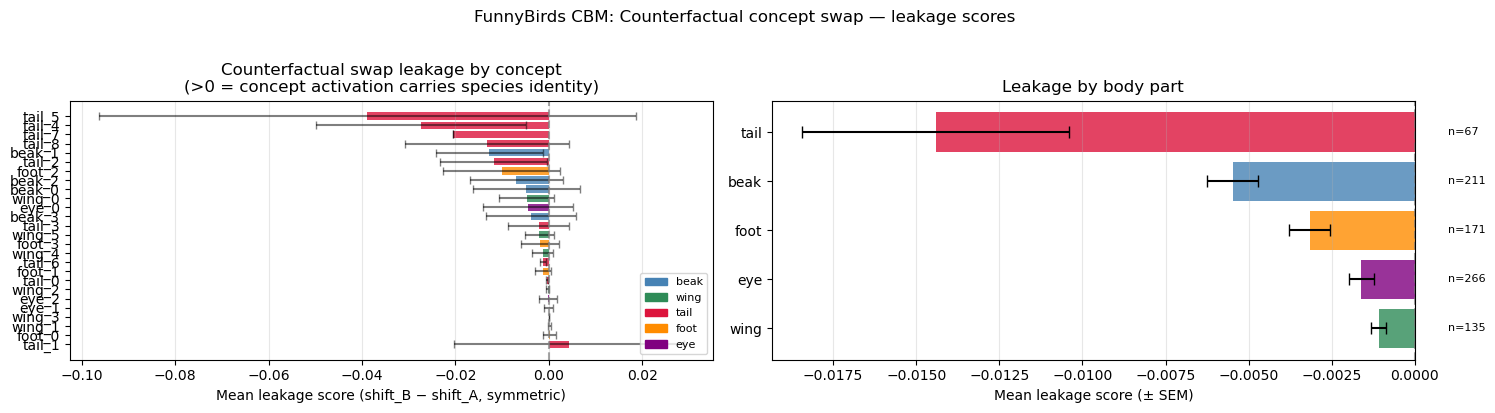

Saved fb_cbm_swap_leakage.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Panel A: leakage_mean per concept, coloured by part
ax = axes[0]
colors = [PART_COLORS[p] for p in concept_agg['part']]
ax.barh(concept_agg['concept'], concept_agg['leakage_mean'], color=colors, alpha=0.8)
ax.errorbar(
    concept_agg['leakage_mean'], range(len(concept_agg)),
    xerr=concept_agg['leakage_std'].fillna(0),
    fmt='none', color='black', alpha=0.5, capsize=3,
)
ax.axvline(0, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('Mean leakage score (shift_B − shift_A, symmetric)')
ax.set_title('Counterfactual swap leakage by concept\n'
             '(>0 = concept activation carries species identity)')
ax.legend(handles=[Patch(color=c, label=p) for p, c in PART_COLORS.items()],
          fontsize=8, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)

# Panel B: per-part aggregation
ax = axes[1]
part_agg = swap_df.groupby('part')['leakage_sym'].agg(['mean', 'sem', 'size']).reset_index()
part_agg = part_agg.sort_values('mean', ascending=False)
ax.barh(part_agg['part'],
        part_agg['mean'],
        xerr=part_agg['sem'],
        color=[PART_COLORS[p] for p in part_agg['part']],
        alpha=0.8, capsize=4)
for _, r in part_agg.iterrows():
    ax.text(max(r['mean'], 0) + 0.001, list(part_agg['part']).index(r['part']),
            f"n={int(r['size'])}", va='center', fontsize=8)
ax.axvline(0, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('Mean leakage score (± SEM)')
ax.set_title('Leakage by body part')
ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('FunnyBirds CBM: Counterfactual concept swap — leakage scores', y=1.02)
plt.tight_layout()
plt.savefig('fb_cbm_swap_leakage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fb_cbm_swap_leakage.png')

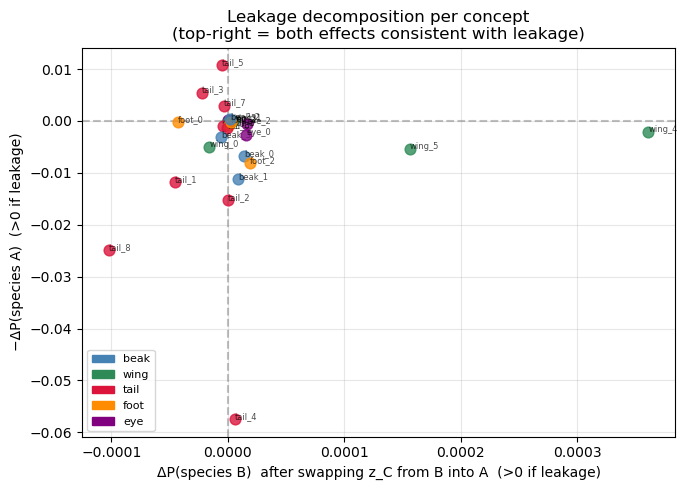

Saved fb_cbm_swap_decomp.png


In [29]:
# Decompose leakage: ΔP(B) vs −ΔP(A) per concept
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in concept_agg.iterrows():
    color = PART_COLORS[row['part']]
    ax.scatter(row['shift_B_mean'], -row['shift_A_mean'],
               color=color, s=60, alpha=0.8, zorder=3)
    ax.annotate(row['concept'],
                (row['shift_B_mean'], -row['shift_A_mean']),
                fontsize=6, alpha=0.7)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('ΔP(species B)  after swapping z_C from B into A  (>0 if leakage)')
ax.set_ylabel('−ΔP(species A)  (>0 if leakage)')
ax.set_title('Leakage decomposition per concept\n'
             '(top-right = both effects consistent with leakage)')
ax.legend(handles=[Patch(color=c, label=p) for p, c in PART_COLORS.items()], fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fb_cbm_swap_decomp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fb_cbm_swap_decomp.png')

## 7. Species-identity probe on z

Train a linear classifier `z [26-dim] → species_id`.
High accuracy = the 26-dimensional concept bottleneck encodes species identity, not
just concept presence.  Compare against a random-Gaussian baseline.

In [17]:
class LinearProbe(nn.Module):
    def __init__(self, in_dim: int, n_classes: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        return self.fc(x)


def train_classifier(
    X_tr, y_tr, X_te, y_te,
    n_classes: int, seed: int = 0,
    lr: float = 1e-2, wd: float = 1e-4,
    epochs: int = 30, batch: int = 512,
) -> float:
    """Train linear multiclass probe; return test accuracy."""
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    X_tr = X_tr.to(device); X_te = X_te.to(device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long, device=device)
    y_te_t = torch.tensor(y_te, dtype=torch.long, device=device)

    probe   = LinearProbe(X_tr.shape[1], n_classes).to(device)
    opt     = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    n = X_tr.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx  = perm[i:i+batch]
            loss = loss_fn(probe(X_tr[idx]), y_tr_t[idx])
            opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        probe.eval()
        preds = probe(X_te).argmax(dim=1)
        return float((preds == y_te_t).float().mean())


print('Defined: LinearProbe  train_classifier')

Defined: LinearProbe  train_classifier


In [18]:
# Full z (26-dim) → species probe
acc_full = train_classifier(
    z_tr, sids_tr, z_te, sids_te, n_classes=N_SPECIES, epochs=PROBE_EPOCHS,
)
print(f'Species probe on z (all 26 concepts): {acc_full:.4f}')
print(f'  chance level: {1/N_SPECIES:.4f}  ({N_SPECIES} classes)')

# Random baseline: same shape, Gaussian noise
torch.manual_seed(42)
acc_rand = train_classifier(
    torch.randn_like(z_tr), sids_tr,
    torch.randn_like(z_te), sids_te,
    n_classes=N_SPECIES, epochs=PROBE_EPOCHS,
)
print(f'Species probe on random baseline:    {acc_rand:.4f}')

# avgpool backbone baseline: how much species info before the bottleneck?
acc_avgpool = train_classifier(
    avg_tr, sids_tr, avg_te, sids_te, n_classes=N_SPECIES, epochs=PROBE_EPOCHS,
)
print(f'Species probe on avgpool (backbone): {acc_avgpool:.4f}')

Species probe on z (all 26 concepts): 0.9780
  chance level: 0.0200  (50 classes)
Species probe on random baseline:    0.0320
Species probe on avgpool (backbone): 0.9760


In [19]:
# Per-concept probe: z[:, c] (single scalar) → species_id
per_concept_acc = {}
for c_idx, c_name in enumerate(CONCEPT_NAMES):
    acc = train_classifier(
        z_tr[:, c_idx:c_idx+1], sids_tr,
        z_te[:, c_idx:c_idx+1], sids_te,
        n_classes=N_SPECIES, epochs=PROBE_EPOCHS,
    )
    per_concept_acc[c_name] = acc

probe_acc_df = pd.DataFrame([
    {'concept': c, 'species_acc': a, 'part': CONCEPT_TO_PART[c]}
    for c, a in per_concept_acc.items()
]).sort_values('species_acc', ascending=False)

print(f'\nPer-concept species decodability (chance={1/N_SPECIES:.3f}):')
display(probe_acc_df)


Per-concept species decodability (chance=0.020):


,concept,species_acc,part
10,wing_3,0.070,wing
18,tail_1,0.062,tail
22,tail_5,0.056,tail
24,tail_7,0.054,tail
2,beak_2,0.054,beak
14,foot_1,0.054,foot
8,wing_1,0.052,wing
20,tail_3,0.052,tail
6,eye_2,0.048,eye
5,eye_1,0.048,eye


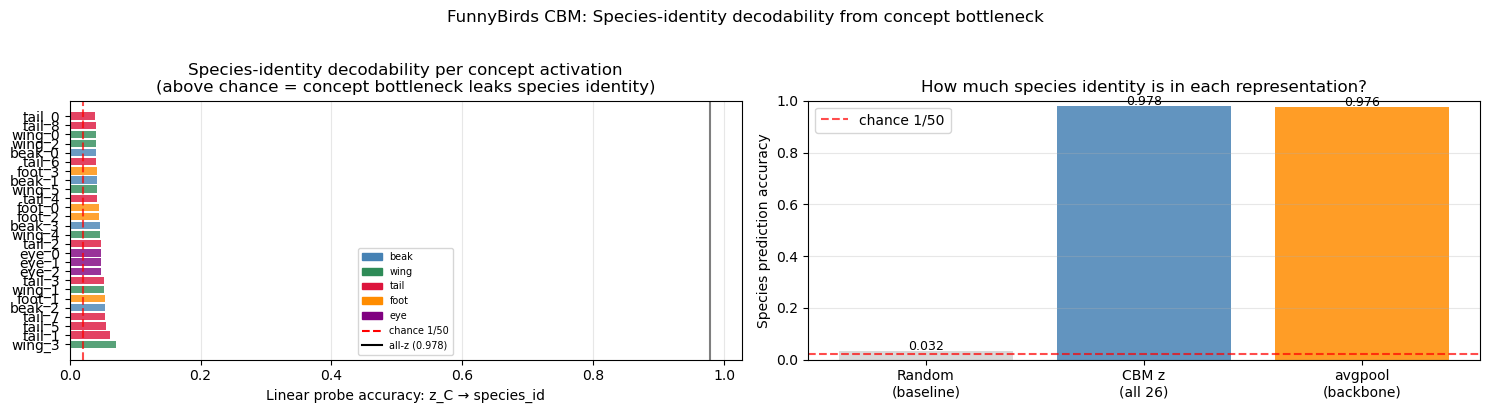

Saved fb_cbm_species_probe.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Panel A: per-concept species probe accuracy
ax = axes[0]
colors = [PART_COLORS[p] for p in probe_acc_df['part']]
ax.barh(probe_acc_df['concept'], probe_acc_df['species_acc'], color=colors, alpha=0.8)
ax.axvline(1/N_SPECIES, color='red', ls='--', alpha=0.7, label=f'chance 1/{N_SPECIES}')
ax.axvline(acc_full,    color='black', ls='-', alpha=0.5, label=f'all-z ({acc_full:.3f})')
ax.set_xlabel('Linear probe accuracy: z_C → species_id')
ax.set_title('Species-identity decodability per concept activation\n'
             '(above chance = concept bottleneck leaks species identity)')
ax.legend(handles=[
    *[Patch(color=c, label=p) for p, c in PART_COLORS.items()],
    Line2D([0],[0], color='red',   ls='--', label=f'chance 1/{N_SPECIES}'),
    Line2D([0],[0], color='black',          label=f'all-z ({acc_full:.3f})'),
], fontsize=7)
ax.grid(True, axis='x', alpha=0.3)

# Panel B: summary bar — backbone avgpool vs z vs random
ax = axes[1]
labels = ['Random\n(baseline)', 'CBM z\n(all 26)', 'avgpool\n(backbone)']
accs   = [acc_rand, acc_full, acc_avgpool]
ax.bar(labels, accs, color=['lightgray', 'steelblue', 'darkorange'], alpha=0.85)
ax.axhline(1/N_SPECIES, color='red', ls='--', alpha=0.7, label=f'chance 1/{N_SPECIES}')
for i, a in enumerate(accs):
    ax.text(i, a + 0.005, f'{a:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Species prediction accuracy')
ax.set_title('How much species identity is in each representation?')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, min(1.0, max(accs) * 1.2))

plt.suptitle('FunnyBirds CBM: Species-identity decodability from concept bottleneck', y=1.02)
plt.tight_layout()
plt.savefig('fb_cbm_species_probe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fb_cbm_species_probe.png')

## 8. Per-pair binary discriminability in z_C

For each all-positive pair (A, B, concept C): train `z_C [scalar] → {species A, species B}`.
Accuracy > 0.5 = z_C distinguishes the two species — mechanistic evidence that the concept
activation carries species-specific signal beyond whether the concept is present.

In [21]:
def binary_species_disc(sid_A: int, sid_B: int, concept_idx: int) -> float:
    """
    Train z[:, concept_idx] → {0=A, 1=B} binary probe.
    Returns test accuracy (0.5 = chance).  NaN if not enough data.
    """
    mask_tr = np.isin(sids_tr, [sid_A, sid_B])
    mask_te = np.isin(sids_te, [sid_A, sid_B])
    if mask_tr.sum() < 4 or mask_te.sum() < 2:
        return float('nan')
    X_tr = z_tr[mask_tr, concept_idx:concept_idx+1]
    X_te = z_te[mask_te, concept_idx:concept_idx+1]
    y_tr = (sids_tr[mask_tr] == sid_B).astype(int)
    y_te = (sids_te[mask_te] == sid_B).astype(int)
    return train_classifier(X_tr, y_tr, X_te, y_te, n_classes=2, epochs=PROBE_EPOCHS)


print('Defined: binary_species_disc')

Defined: binary_species_disc


In [22]:
disc_rows = []
for c_idx, c_name in enumerate(CONCEPT_NAMES):
    positive_sids = np.where(cc_matrix[:, c_idx] == 1)[0]
    if len(positive_sids) < 2:
        continue
    for sid_A, sid_B in combinations(positive_sids, 2):
        acc = binary_species_disc(sid_A, sid_B, c_idx)
        if not np.isnan(acc):
            disc_rows.append({
                'sid_A': int(sid_A), 'sid_B': int(sid_B),
                'concept': c_name, 'concept_idx': c_idx,
                'part': CONCEPT_TO_PART[c_name],
                'disc_acc': float(acc),
            })

disc_df = pd.DataFrame(disc_rows)
disc_df['disc_above_chance'] = disc_df['disc_acc'] > 0.5

print(f'Binary discriminability: {len(disc_df)} pair-concept combos')
print(f'  mean disc_acc={disc_df["disc_acc"].mean():.4f}  '
      f'frac>0.5: {disc_df["disc_above_chance"].mean():.3f}')

disc_concept = (
    disc_df.groupby(['concept', 'part'])[['disc_acc', 'disc_above_chance']]
    .mean().reset_index()
    .sort_values('disc_acc', ascending=False)
)
display(disc_concept)

Binary discriminability: 850 pair-concept combos
  mean disc_acc=0.5119  frac>0.5: 0.280


,concept,part,disc_acc,disc_above_chance
16,tail_5,tail,0.633333,0.800000
18,tail_7,tail,0.600000,1.000000
13,tail_2,tail,0.575000,0.833333
12,tail_1,tail,0.566667,0.666667
19,tail_8,tail,0.546667,0.666667
17,tail_6,tail,0.533333,0.666667
24,wing_4,wing,0.530357,0.464286
2,beak_2,beak,0.526667,0.533333
0,beak_0,beak,0.526250,0.433333
25,wing_5,wing,0.525000,0.428571


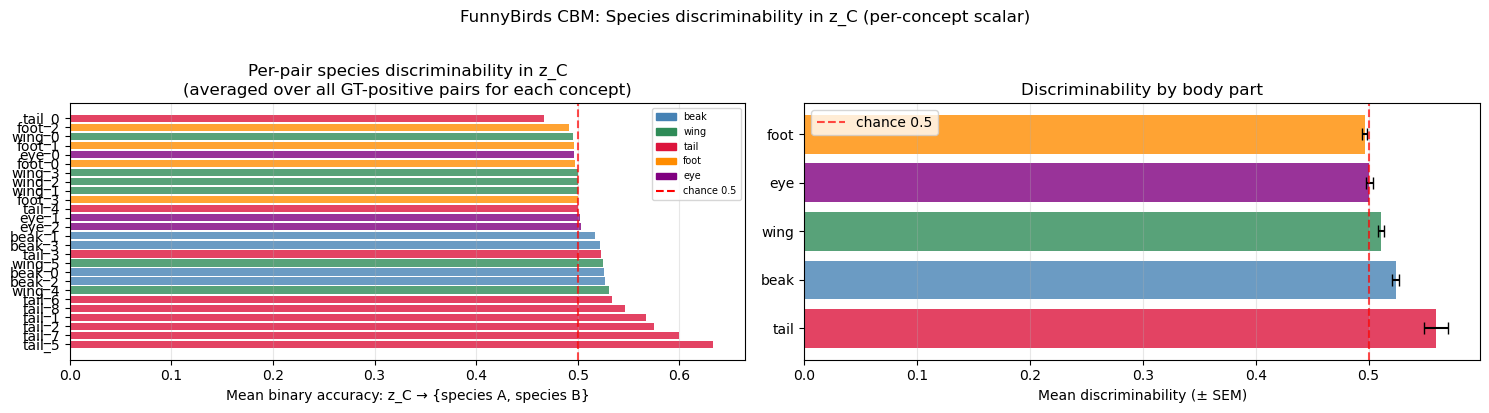

Saved fb_cbm_binary_disc.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

ax = axes[0]
colors = [PART_COLORS[p] for p in disc_concept['part']]
ax.barh(disc_concept['concept'], disc_concept['disc_acc'], color=colors, alpha=0.8)
ax.axvline(0.5, color='red', ls='--', alpha=0.7, label='chance (0.5)')
ax.set_xlabel('Mean binary accuracy: z_C → {species A, species B}')
ax.set_title('Per-pair species discriminability in z_C\n'
             '(averaged over all GT-positive pairs for each concept)')
ax.legend(handles=[
    *[Patch(color=c, label=p) for p, c in PART_COLORS.items()],
    Line2D([0],[0], color='red', ls='--', label='chance 0.5'),
], fontsize=7)
ax.grid(True, axis='x', alpha=0.3)

ax = axes[1]
part_disc = (
    disc_df.groupby('part')['disc_acc']
    .agg(['mean', 'sem'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
ax.barh(part_disc['part'],
        part_disc['mean'],
        xerr=part_disc['sem'],
        color=[PART_COLORS[p] for p in part_disc['part']],
        alpha=0.8, capsize=4)
ax.axvline(0.5, color='red', ls='--', alpha=0.7, label='chance 0.5')
ax.set_xlabel('Mean discriminability (± SEM)')
ax.set_title('Discriminability by body part')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('FunnyBirds CBM: Species discriminability in z_C (per-concept scalar)', y=1.02)
plt.tight_layout()
plt.savefig('fb_cbm_binary_disc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fb_cbm_binary_disc.png')

## 9. Three-level evidence: correlation across measures

| Analysis | Level | Measure |
|---|---|---|
| Recall gap (`fb_recallv2.ipynb`) | Behavioural | Probe fires differently across species |
| Counterfactual swap | Causal | Replacing z_C shifts species prediction |
| Binary discriminability | Mechanistic | z_C alone separates two species |

Per-concept correlation across the three measures — if they agree, the evidence
for species-identity leakage through the concept bottleneck is robust.

In [24]:
# Merge the three concept-level measures
merged = (
    concept_agg[['concept', 'part', 'leakage_mean']]
    .merge(disc_concept[['concept', 'disc_acc']], on='concept', how='inner')
    .merge(probe_acc_df[['concept', 'species_acc']], on='concept', how='inner')
)

# Optionally load recall gap from fb_recallv2 output
CBM_SPECIES_CSV = Path('fb_cbm_species.csv')
if CBM_SPECIES_CSV.exists():
    sp_csv = pd.read_csv(CBM_SPECIES_CSV)
    if {'attr', 'recall'}.issubset(sp_csv.columns):
        recall_gap = (
            sp_csv.groupby('attr')['recall']
            .apply(lambda x: x.max() - x.min())
            .reset_index(name='recall_range')
            .rename(columns={'attr': 'concept'})
        )
        merged = merged.merge(recall_gap, on='concept', how='left')
        print('Merged recall_range from fb_cbm_species.csv')
    else:
        merged['recall_range'] = np.nan
else:
    merged['recall_range'] = np.nan
    print('[info] fb_cbm_species.csv not found — run fb_recallv2.ipynb first')

display(merged)

Merged recall_range from fb_cbm_species.csv


,concept,part,leakage_mean,disc_acc,species_acc,recall_range
0,tail_1,tail,4.320025e-03,0.566667,0.062,0.2
1,foot_0,foot,2.141974e-04,0.497727,0.044,0.0
2,wing_1,wing,1.373339e-04,0.500000,0.052,0.0
3,wing_3,wing,6.172883e-07,0.500000,0.070,0.0
4,eye_1,eye,-2.255716e-05,0.501818,0.048,0.1
5,eye_2,eye,-1.938441e-04,0.502917,0.048,0.1
6,wing_2,wing,-1.948633e-04,0.500000,0.040,0.0
7,tail_0,tail,-4.256239e-04,0.466667,0.038,0.0
8,foot_1,foot,-1.184285e-03,0.496667,0.054,0.0
9,tail_6,tail,-1.188462e-03,0.533333,0.040,0.0


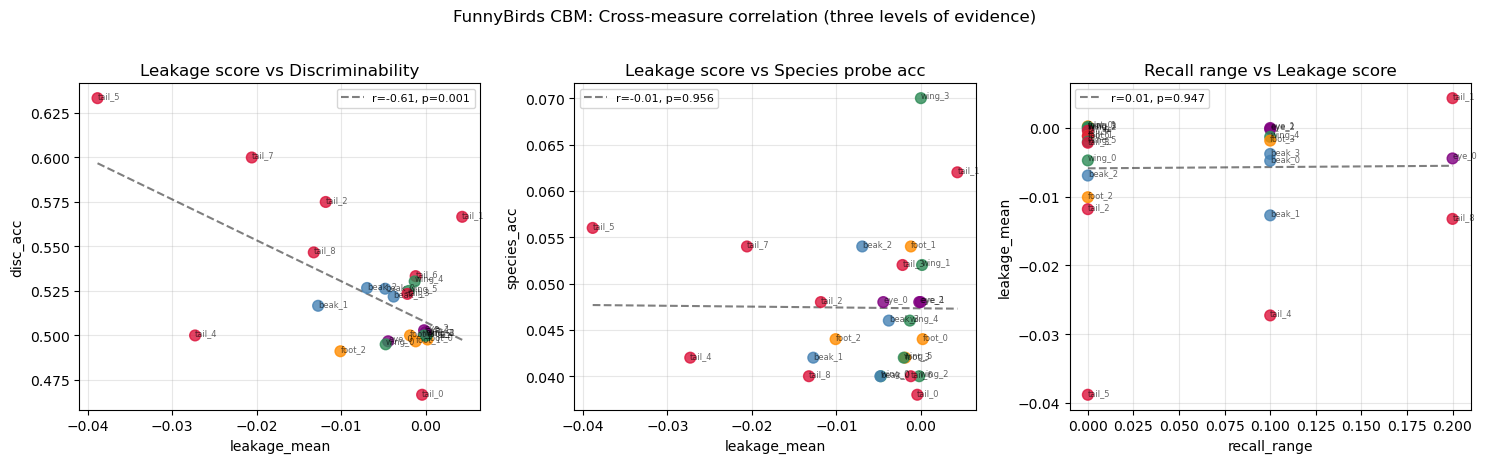

Saved fb_cbm_evidence_correlation.png


In [30]:
has_recall = merged['recall_range'].notna().any()
ncols = 3 if has_recall else 2
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5))

pairs_to_plot = [
    ('leakage_mean', 'disc_acc',    'Leakage score vs Discriminability'),
    ('leakage_mean', 'species_acc', 'Leakage score vs Species probe acc'),
]
if has_recall:
    pairs_to_plot.append(('recall_range', 'leakage_mean', 'Recall range vs Leakage score'))

for ax, (x_col, y_col, title) in zip(axes, pairs_to_plot):
    sub = merged[[x_col, y_col, 'concept', 'part']].dropna()
    colors_sub = [PART_COLORS[p] for p in sub['part']]
    ax.scatter(sub[x_col], sub[y_col], c=colors_sub, s=60, alpha=0.8, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['concept'], (row[x_col], row[y_col]), fontsize=6, alpha=0.6)
    if len(sub) > 2:
        r, p = stats.pearsonr(sub[x_col], sub[y_col])
        m, b = np.polyfit(sub[x_col], sub[y_col], 1)
        xs   = np.array([sub[x_col].min(), sub[x_col].max()])
        ax.plot(xs, m * xs + b, 'k--', alpha=0.5, label=f'r={r:.2f}, p={p:.3f}')
        ax.legend(fontsize=8)
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.set_title(title); ax.grid(True, alpha=0.3)

plt.suptitle('FunnyBirds CBM: Cross-measure correlation (three levels of evidence)', y=1.02)
plt.tight_layout()
plt.savefig('fb_cbm_evidence_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fb_cbm_evidence_correlation.png')

## 10. Summary

### What we measured

| Measure | Value | Interpretation |
|---|---|---|
| Species probe on z (all 26) | `acc_full` | How much species info survives the bottleneck |
| Species probe on avgpool (backbone) | `acc_avgpool` | Upstream ceiling |
| Mean leakage score (swap) | `leakage_sym` | Causal: z_C carries species signal |
| Mean binary discriminability | `disc_acc` | z_C scalar separates species |

### Interpreting leakage_sym

`leakage_sym > 0` for a concept means: swapping z_C from species B into species A
consistently raised P(B) and lowered P(A).  The bottleneck value is not purely
concept-predictive — it also carries which species produced it.

A concept with **high leakage + high discriminability + high species probe acc**
is the strongest case: all three independent analyses agree it leaks species identity.

### Next: MCBM comparison

Run the MCBM version of this notebook (to be created) across γ values.
The IB penalty should reduce `leakage_sym` and `disc_acc` while preserving
concept accuracy — that is the direct mechanistic test of the backwash hypothesis.

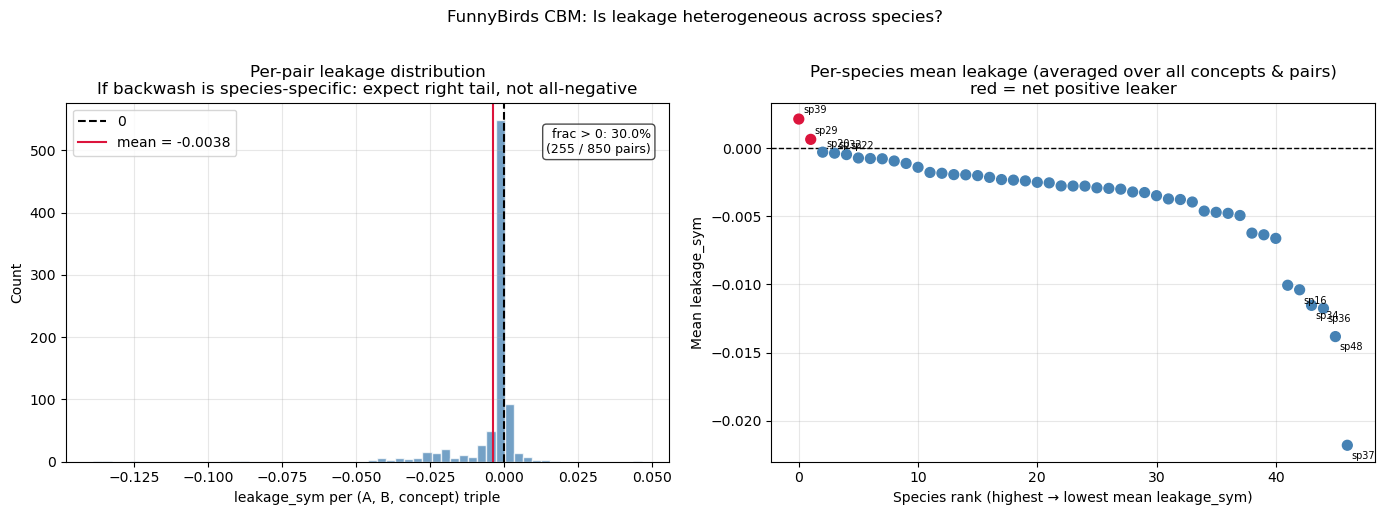

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full histogram of per-pair leakage_sym
ax = axes[0]
vals = swap_df['leakage_sym'].values
frac_pos = (vals > 0).mean()
ax.hist(vals, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(0,           color='black',  lw=1.5, ls='--', label='0')
ax.axvline(vals.mean(), color='crimson', lw=1.5, ls='-',
           label=f'mean = {vals.mean():.4f}')
ax.text(0.97, 0.93, f'frac > 0: {frac_pos:.1%}\n({(vals>0).sum()} / {len(vals)} pairs)',
        transform=ax.transAxes, fontsize=9, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.set_xlabel('leakage_sym per (A, B, concept) triple')
ax.set_ylabel('Count')
ax.set_title('Per-pair leakage distribution\n'
             'If backwash is species-specific: expect right tail, not all-negative')
ax.legend(); ax.grid(True, alpha=0.3)
t
# Right: per-species mean leakage, ranked
ax = axes[1]
sp_leak = pd.concat([
    swap_df[['sid_A', 'leakage_sym']].rename(columns={'sid_A': 'sid'}),
    swap_df[['sid_B', 'leakage_sym']].rename(columns={'sid_B': 'sid'}),
]).groupby('sid')['leakage_sym'].mean().reset_index(name='mean_leakage') \
  .sort_values('mean_leakage', ascending=False).reset_index(drop=True)

sp_colors = ['crimson' if v > 0 else 'steelblue' for v in sp_leak['mean_leakage']]
ax.scatter(range(len(sp_leak)), sp_leak['mean_leakage'], c=sp_colors, s=50, zorder=3)
ax.axhline(0, color='black', lw=1, ls='--')
for rank, row in sp_leak.head(5).iterrows():
    ax.annotate(f"sp{int(row['sid'])}", (rank, row['mean_leakage']),
                textcoords='offset points', xytext=(3, 4), fontsize=7)
for rank, row in sp_leak.tail(5).iterrows():
    ax.annotate(f"sp{int(row['sid'])}", (rank, row['mean_leakage']),
                textcoords='offset points', xytext=(3, -10), fontsize=7)
ax.set_xlabel('Species rank (highest → lowest mean leakage_sym)')
ax.set_ylabel('Mean leakage_sym')
ax.set_title('Per-species mean leakage (averaged over all concepts & pairs)\n'
             'red = net positive leaker')
ax.grid(True, alpha=0.3)

plt.suptitle('FunnyBirds CBM: Is leakage heterogeneous across species?', y=1.02)
plt.tight_layout()
plt.savefig('fb_cbm_leakage_dist.png', dpi=150, bbox_inches='tight')
plt.show()

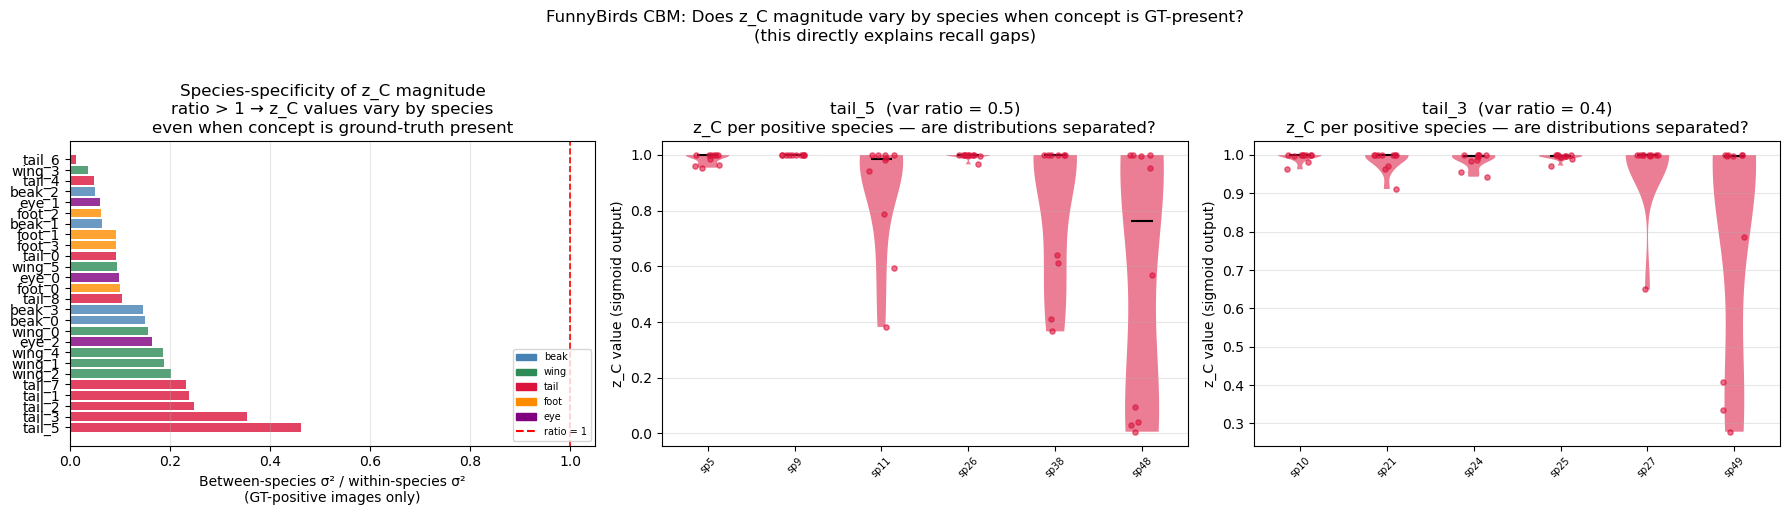

In [36]:
# Compute between/within-species variance of z_C for GT-positive images
var_rows = []
for c_idx, c_name in enumerate(CONCEPT_NAMES):
    pos_sids = np.where(cc_matrix[:, c_idx] == 1)[0]
    sv = [z_te[sids_te == sid, c_idx].numpy()
          for sid in pos_sids if (sids_te == sid).sum() >= 1]
    if len(sv) < 2:
        continue
    sp_means = np.array([v.mean() for v in sv])
    sp_vars  = np.array([v.var()  for v in sv])
    var_rows.append({
        'concept': c_name,
        'part':    CONCEPT_TO_PART[c_name],
        'between': float(np.var(sp_means)),
        'within':  float(np.mean(sp_vars)),
        'ratio':   float(np.var(sp_means) / (np.mean(sp_vars) + 1e-8)),
    })
var_df = pd.DataFrame(var_rows).sort_values('ratio', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: variance ratio bar per concept
ax = axes[0]
colors_vr = [PART_COLORS[p] for p in var_df['part']]
ax.barh(var_df['concept'], var_df['ratio'], color=colors_vr, alpha=0.8)
ax.axvline(1, color='red', ls='--', lw=1.2, label='ratio = 1')
ax.set_xlabel('Between-species σ² / within-species σ²\n(GT-positive images only)')
ax.set_title('Species-specificity of z_C magnitude\n'
             'ratio > 1 → z_C values vary by species\n'
             'even when concept is ground-truth present')
ax.legend(handles=[
    *[Patch(color=c, label=p) for p, c in PART_COLORS.items()],
    Line2D([0],[0], color='red', ls='--', label='ratio = 1'),
], fontsize=7, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)

# Middle & Right: z_C violin per species for top-2 concepts by variance ratio
top2 = var_df.head(2)['concept'].tolist()
for ax, c_name in zip(axes[1:], top2):
    c_idx    = CONCEPT_TO_IDX[c_name]
    part     = CONCEPT_TO_PART[c_name]
    pos_sids = sorted(np.where(cc_matrix[:, c_idx] == 1)[0])
    groups   = [(sid, z_te[sids_te == sid, c_idx].numpy())
                for sid in pos_sids if (sids_te == sid).sum() >= 1]
    if not groups:
        continue
    labels_v = [f'sp{sid}' for sid, _ in groups]
    data_v   = [vals for _, vals in groups]

    vp = ax.violinplot(data_v, positions=range(len(data_v)),
                       showmedians=True, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor(PART_COLORS[part])
        body.set_alpha(0.55)
    vp['cmedians'].set_color('black')
    rng = np.random.default_rng(0)
    for i, vals in enumerate(data_v):
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(i + jitter, vals, s=14, color=PART_COLORS[part], alpha=0.6, zorder=3)

    ratio_val = var_df.loc[var_df['concept'] == c_name, 'ratio'].iloc[0]
    ax.set_xticks(range(len(labels_v)))
    ax.set_xticklabels(labels_v, rotation=45, fontsize=7)
    ax.set_ylabel('z_C value (sigmoid output)')
    ax.set_title(f'{c_name}  (var ratio = {ratio_val:.1f})\n'
                 f'z_C per positive species — are distributions separated?')
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('FunnyBirds CBM: Does z_C magnitude vary by species when concept is GT-present?\n'
             '(this directly explains recall gaps)', y=1.02)
plt.tight_layout()
plt.savefig('fb_cbm_zc_variance.png', dpi=150, bbox_inches='tight')
plt.show()

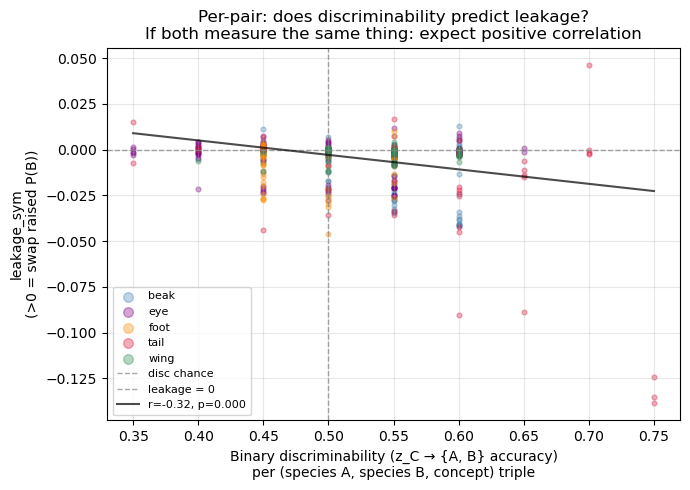

In [37]:
# Merge per-pair swap and discriminability results
pair_merged = swap_df[['sid_A', 'sid_B', 'concept', 'part', 'leakage_sym']].merge(
    disc_df[['sid_A', 'sid_B', 'concept', 'disc_acc']],
    on=['sid_A', 'sid_B', 'concept'], how='inner'
)

fig, ax = plt.subplots(figsize=(7, 5))
for part, grp in pair_merged.groupby('part'):
    ax.scatter(grp['disc_acc'], grp['leakage_sym'],
               color=PART_COLORS[part], s=12, alpha=0.35, label=part)
ax.axvline(0.5, color='gray', ls='--', lw=1, alpha=0.7, label='disc chance')
ax.axhline(0,   color='gray', ls='--', lw=1, alpha=0.7, label='leakage = 0')
if len(pair_merged) > 2:
    r, p = stats.pearsonr(pair_merged['disc_acc'], pair_merged['leakage_sym'])
    m, b = np.polyfit(pair_merged['disc_acc'], pair_merged['leakage_sym'], 1)
    xs = np.array([pair_merged['disc_acc'].min(), pair_merged['disc_acc'].max()])
    ax.plot(xs, m*xs + b, 'k-', lw=1.5, alpha=0.7, label=f'r={r:.2f}, p={p:.3f}')
ax.set_xlabel('Binary discriminability (z_C → {A, B} accuracy)\nper (species A, species B, concept) triple')
ax.set_ylabel('leakage_sym\n(>0 = swap raised P(B))')
ax.set_title('Per-pair: does discriminability predict leakage?\n'
             'If both measure the same thing: expect positive correlation')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fb_cbm_pairwise_disc_vs_leakage.png', dpi=150, bbox_inches='tight')
plt.show()